In [1]:
import numpy as np
import matplotlib.pyplot as plt
import io
import matplotlib.colors as mcolors
import requests
import xarray as xr

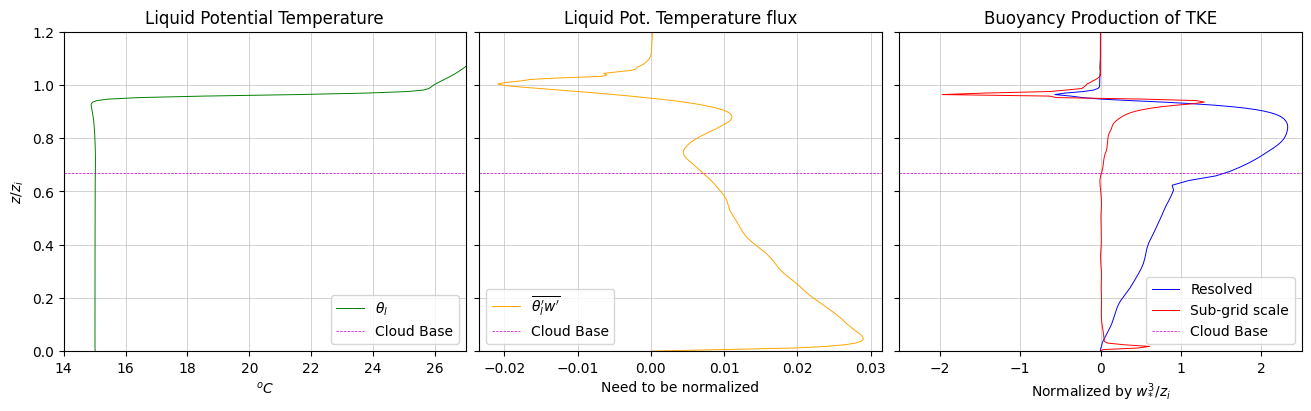

In [13]:
from matplotlib import legend
#---Cloud base (last time steo)---
zi=835
c_base=560/zi

#---Normalization (last time step)---
w_star=0.71
norm=w_star**3/zi

#---Buoyancy data---
url4="https://raw.githubusercontent.com/ChrisPhys97/Bachelor-Thesis/refs/heads/main/data/TKE_Buoyancy_data.nc"
response=requests.get(url4)
data=response.content
bf=xr.open_dataset(io.BytesIO(data),engine="h5netcdf")

fig,ax=plt.subplots(1,3,figsize=(13,4),constrained_layout=True)
ax[0].plot(bf.PTL.values-273.15,bf.z.values,linewidth=0.7,color="g",label=r"$\theta_l$")
ax[1].plot(bf.PTLflux.values,bf.z.values,color="orange",linewidth=0.7,label=r"$\overline{\theta_l^\prime w^\prime}$")
ax[2].plot(bf.BFRES.values/norm,bf.z.values,linewidth=0.7,color="b",label="Resolved")
ax[2].plot(bf.BFSGS.values/norm,bf.z.values,linewidth=0.7,color="r",label="Sub-grid scale")
ax[1].set_yticklabels([])
ax[2].set_yticklabels([])
ax[0].set_title("Liquid Potential Temperature")
ax[1].set_title(r"Liquid Pot. Temperature flux")
ax[2].set_title(r"Buoyancy Production of TKE")
xlabels=["${}^oC$","Need to be normalized","Normalized by $w_{*}^{3}/z_{i}$"]
i=0
for labels in xlabels:
  ax[i].set_xlabel(labels)
  ax[i].set_ylim([0,1.2])
  ax[i].grid(True,linewidth=0.5,alpha=0.8)
  ax[i].axhline(y=c_base,linewidth=0.5,color="m",label="Cloud Base",linestyle="--")
  i+=1
ax[0].set_xlim([14,27])
ax[2].set_xlim([-2.5,2.5])
ax[0].legend(loc="lower right")
ax[1].legend(loc="lower left")
ax[2].legend(loc="lower right")
ax[0].set_ylabel("$z/z_i$")
plt.show()